# Labwork 3

In [8]:
from matplotlib import pyplot as plt
from time import time

import numpy as np
if not hasattr(np, 'row_stack'):
        np.row_stack = np.vstack
        
from numba import config
# Direct Numba's JIT infrastructure to safely link against the driver 
config.CUDA_ENABLE_MINOR_VERSION_COMPATIBILITY = 1
config.CUDA_LOW_OCCUPANCY_WARNINGS = 0

from numba import cuda
from numba import config

blockSizeValues = [32, 64, 128, 256, 512]

img = plt.imread("cat.jpg")
pixelCount = img.shape[0] * img.shape[1]
blockSize = 128
img_flat = img.reshape(pixelCount, 3)


In [9]:
def save_log(device, blocksize, time):
    with open("log.csv", "a") as f:
        f.write(f"{time},{device},{blocksize}\n")

In [10]:
# Grayscale conversion using CPU (for range)
def grayscale_cpu(src, dst):

    for i in range(src.shape[0]):
        g = np.uint8((src[i, 0] + src[i, 1] + src[i, 2]) / 3)
        dst[i] = g


/tmp/ipykernel_382075/4179130516.py:5: RuntimeWarning: overflow encountered in scalar add
  g = np.uint8((src[i, 0] + src[i, 1] + src[i, 2]) / 3)


CPU time: 809.473991394043 ms


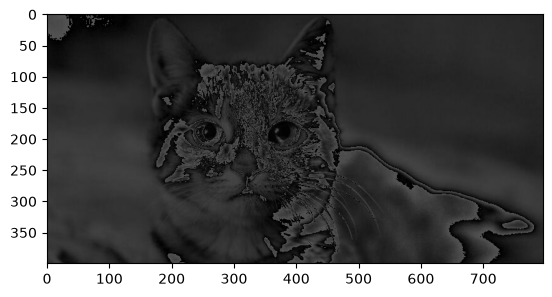

/tmp/ipykernel_382075/4179130516.py:5: RuntimeWarning: overflow encountered in scalar add
  g = np.uint8((src[i, 0] + src[i, 1] + src[i, 2]) / 3)


CPU time: 768.2361602783203 ms


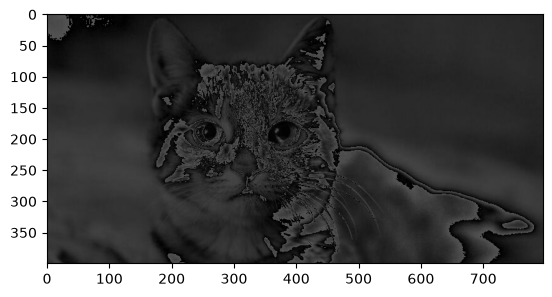

/tmp/ipykernel_382075/4179130516.py:5: RuntimeWarning: overflow encountered in scalar add
  g = np.uint8((src[i, 0] + src[i, 1] + src[i, 2]) / 3)


CPU time: 825.3891468048096 ms


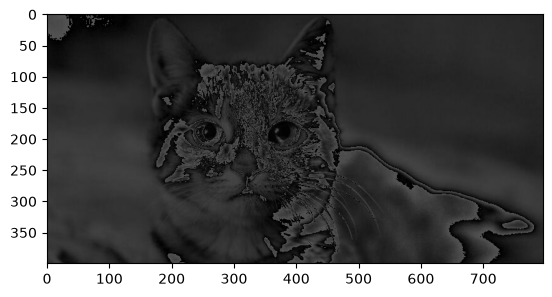

/tmp/ipykernel_382075/4179130516.py:5: RuntimeWarning: overflow encountered in scalar add
  g = np.uint8((src[i, 0] + src[i, 1] + src[i, 2]) / 3)


CPU time: 778.7265777587891 ms


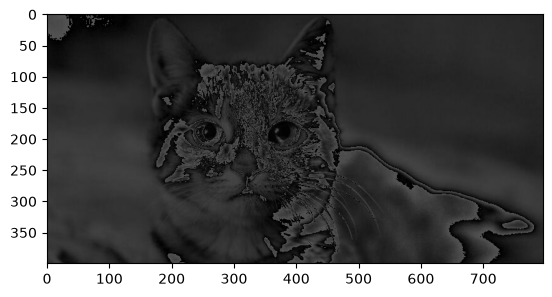

/tmp/ipykernel_382075/4179130516.py:5: RuntimeWarning: overflow encountered in scalar add
  g = np.uint8((src[i, 0] + src[i, 1] + src[i, 2]) / 3)


CPU time: 786.820650100708 ms


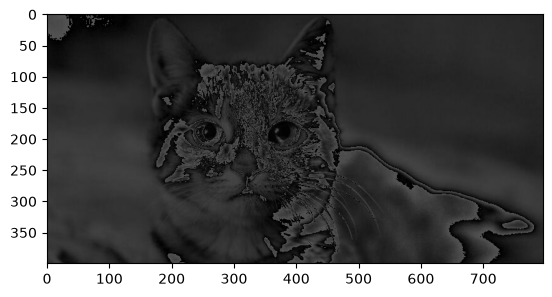

In [ ]:
for blockSize in blockSizeValues:
    gridSize = pixelCount // blockSize
    t0 = time()
    dst = np.empty_like(img_flat)
    grayscale_cpu(img_flat, dst)
    print(f"CPU time: {(time() - t0)*1000} ms")
    save_log("CPU", blockSize, (time() - t0) * 1000)
    # Display the grayscale image
    plt.imshow(dst.reshape(img.shape[0], img.shape[1], 3))

    # save to image
    plt.savefig(f"cat_gray_cpu_{blockSize}.jpg")
    plt.show()   
  

In [12]:
# Grayscale conversion using GPU
@cuda.jit
def grayscale_gpu(src, dst) -> None:

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x # type: ignore
    g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


GPU time: 63.54832649230957 ms


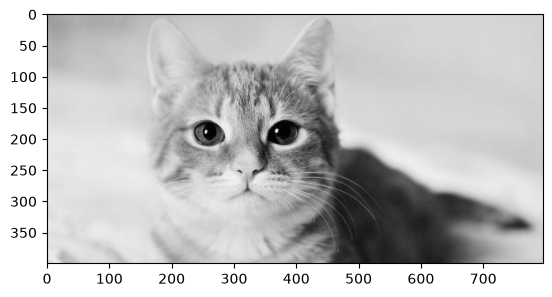

GPU time: 2.499818801879883 ms


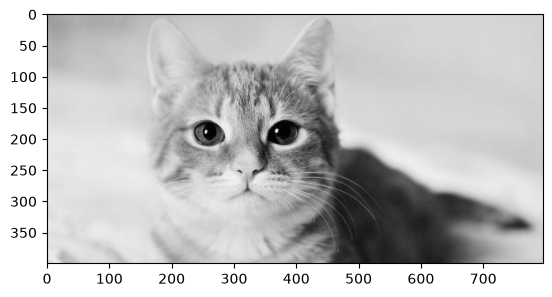

GPU time: 1.3270378112792969 ms


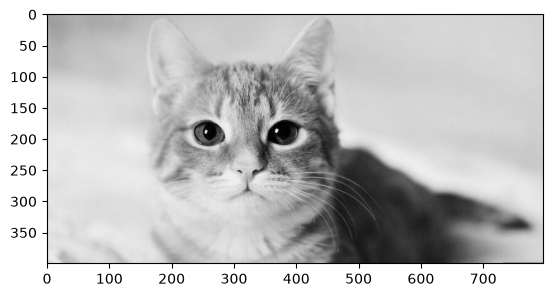

GPU time: 1.1920928955078125 ms


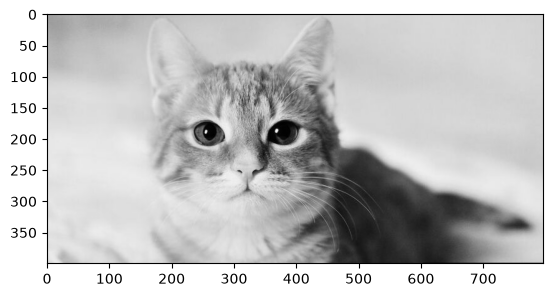

GPU time: 1.268625259399414 ms


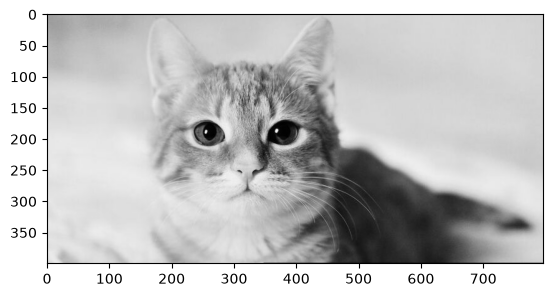

In [13]:
for blockSize in blockSizeValues:
    gridSize = pixelCount // blockSize
    t0 = time()    
    devInput = cuda.to_device(img_flat)
    devOutput = cuda.device_array((pixelCount, 3), dtype=np.uint8)
    grayscale_gpu[gridSize, blockSize](devInput, devOutput)
    hostOutput = devOutput.copy_to_host()

    print(f"GPU time: {(time() - t0)*1000} ms")
    save_log("GPU", blockSize, (time() - t0) * 1000)

    # Display the grayscale image
    plt.imshow(hostOutput.reshape(img.shape[0], img.shape[1], 3))
    plt.savefig(f"cat_gray_gpu_{blockSize}.jpg")
    plt.show()

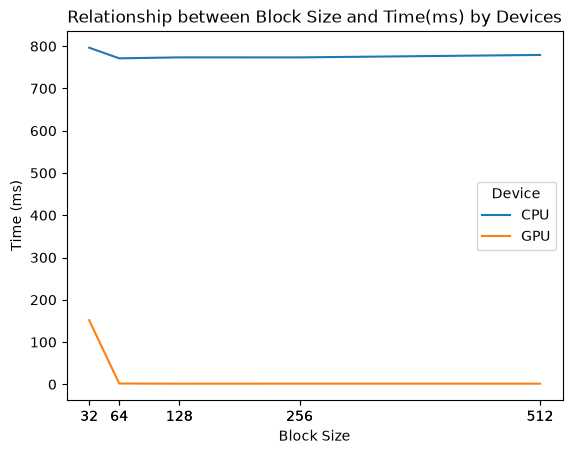

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv("log.csv", header=None, names=["time (ms)", "device", "blockSize"])

mean_df = df.groupby(["device", "blockSize"]).mean().reset_index()

fix, ax = plt.subplots()

for device_name, each_device in mean_df.groupby("device"):
    ax.plot(each_device["blockSize"], each_device["time (ms)"], label=device_name)

plt.xticks(mean_df["blockSize"])
ax.set_xlabel("Block Size")
ax.set_ylabel("Time (ms)")
ax.set_title("Relationship between Block Size and Time(ms) by Devices")

ax.legend(title="Device")

plt.savefig("relationship.jpg", bbox_inches="tight")
plt.show()
